# 07 — Validación (Fase 3H)

¿Las recomendaciones son consistentes, interpretables, reducen carga cognitiva, aportan valor clínico y son auditables?

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

CD = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(CD / "src"))
from predia_cdss import config
DS, MET, FIG, RUL, DASH = CD/"datasets", CD/"metrics", CD/"figures", CD/"rules", CD/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)
print("Entorno listo:", CD)


Entorno listo: /home/wowo/Descargas/predia/ml-research/clinical_decision_support


In [2]:
v = load(MET/'validation.json')
import json as _j; print(_j.dumps(v, indent=2, ensure_ascii=False))

{
  "consistencia": {
    "spearman_riesgo_priority": 0.953,
    "spearman_ces_priority": -0.928,
    "monotonic_risk": true,
    "ces_inverse": true
  },
  "interpretabilidad": {
    "n_pacientes": 400,
    "pct_recs_con_razon": 1.0,
    "pct_con_explicacion": 0.875
  },
  "carga_cognitiva": {
    "acciones_catalogo": 9,
    "media_acciones_mostradas": 4.62,
    "reduccion_pct": 48.7
  },
  "valor_clinico": {
    "spearman_priority_time_to_event": -0.06,
    "priority_medio_con_deterioro": 54.0,
    "priority_medio_sin_deterioro": 17.6,
    "separa_grupos": true
  },
  "auditabilidad": {
    "n_pacientes": 400,
    "pct_auditable": 1.0
  }
}


## Lectura de los resultados

In [3]:
c=v['consistencia']; vc=v['valor_clinico']; cl=v['carga_cognitiva']
print(f"1. Consistencia: ρ(riesgo,prioridad)={c['spearman_riesgo_priority']} (monótono)")
print(f"2. Interpretabilidad: {v['interpretabilidad']['pct_recs_con_razon']:.0%} recs con razón")
print(f"3. Carga cognitiva: −{cl['reduccion_pct']}% vs catálogo completo")
print(f"4. Valor clínico: prioridad {vc['priority_medio_con_deterioro']} (deterioro) "
      f"vs {vc['priority_medio_sin_deterioro']} (sin)")
print(f"5. Auditabilidad: {v['auditabilidad']['pct_auditable']:.0%} trazable")

1. Consistencia: ρ(riesgo,prioridad)=0.953 (monótono)
2. Interpretabilidad: 100% recs con razón
3. Carga cognitiva: −48.7% vs catálogo completo
4. Valor clínico: prioridad 54.0 (deterioro) vs 17.6 (sin)
5. Auditabilidad: 100% trazable


## Dashboards Asistente Clínico (todos los arquetipos)

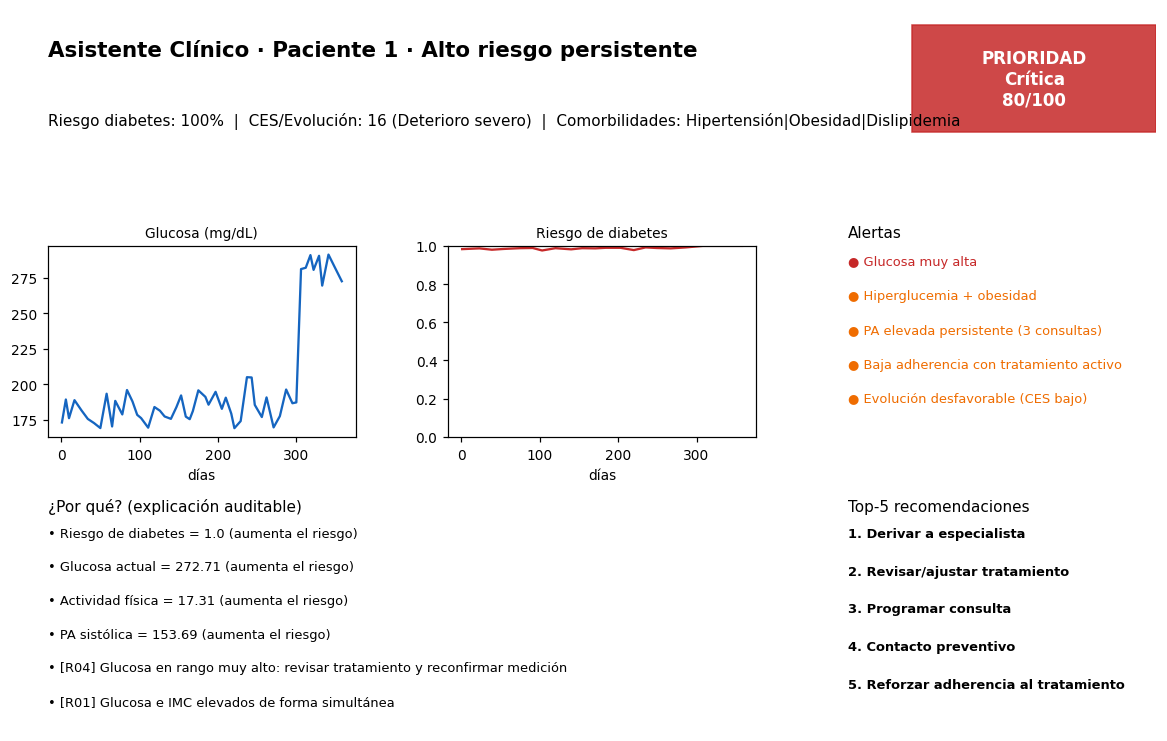

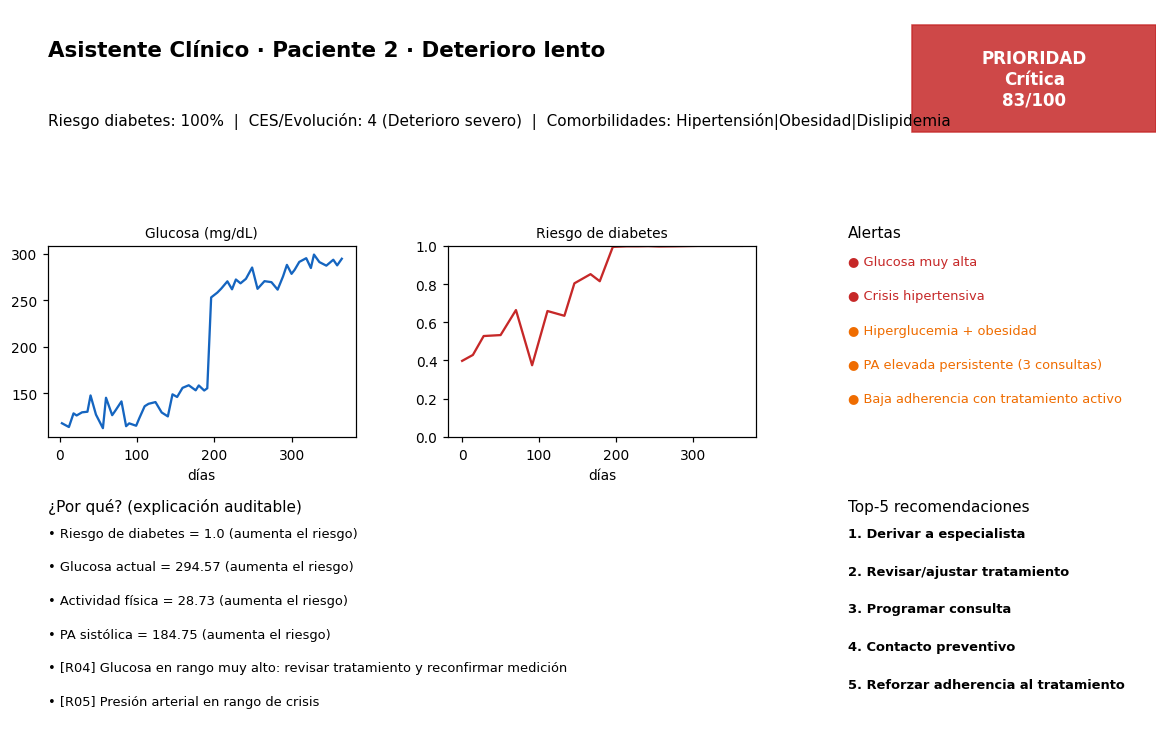

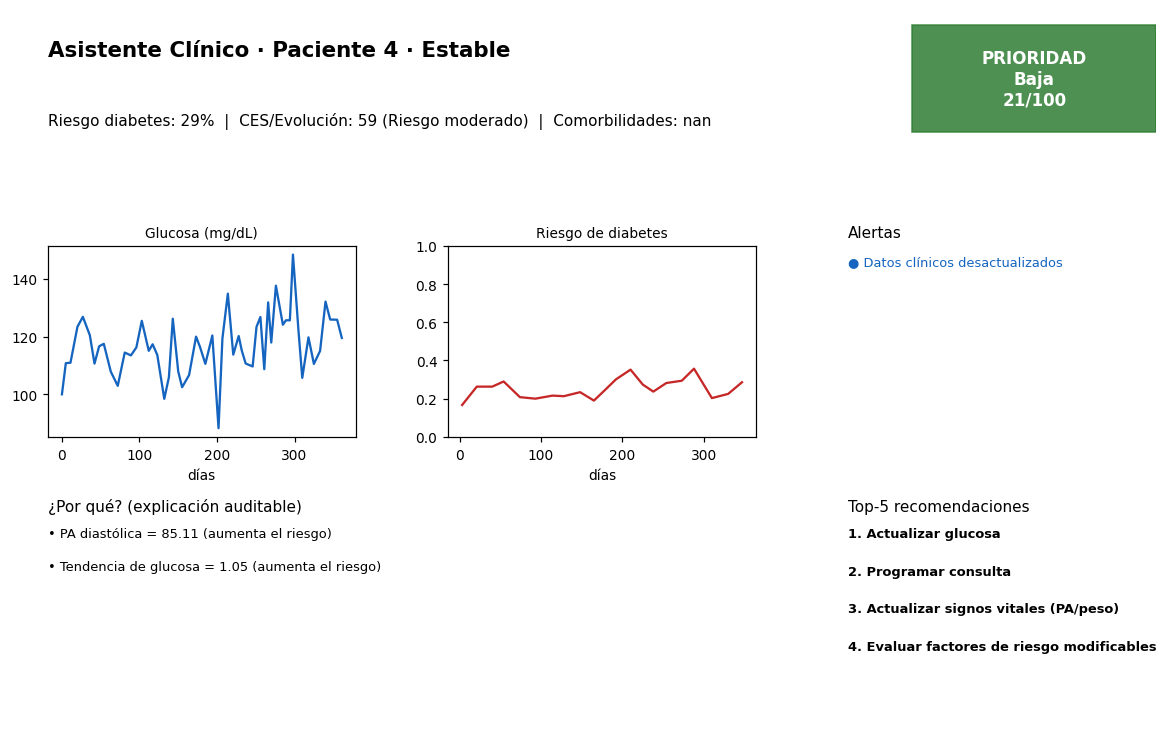

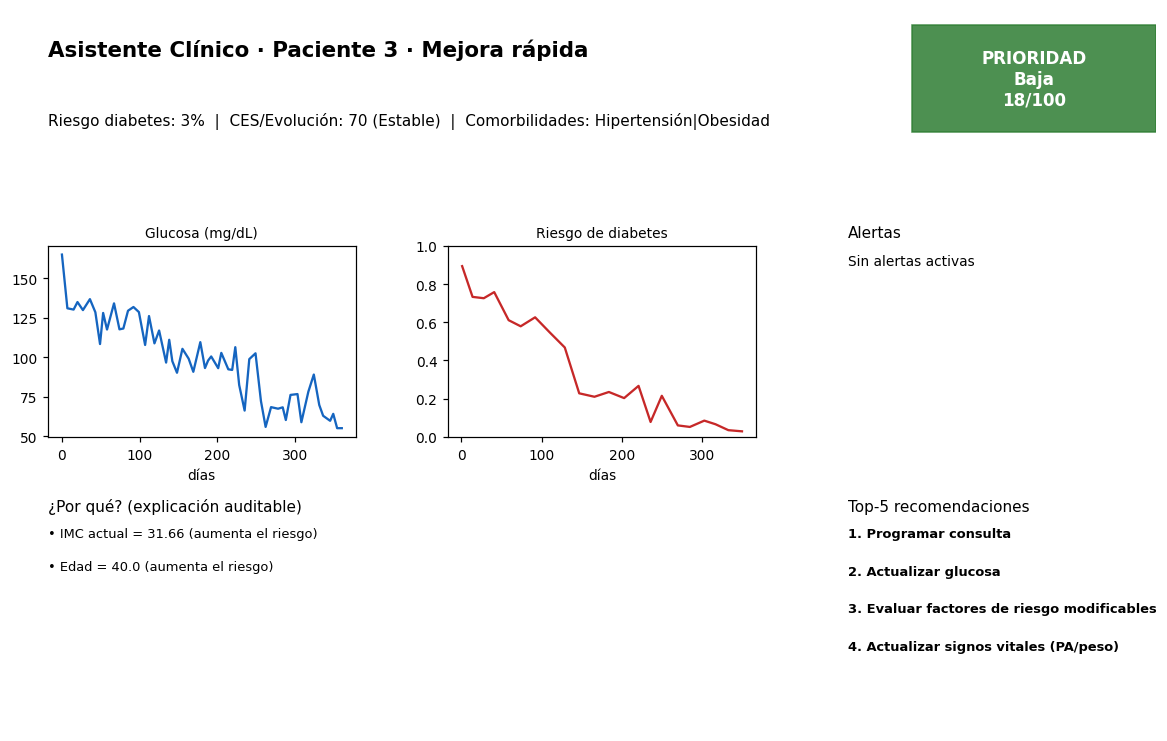

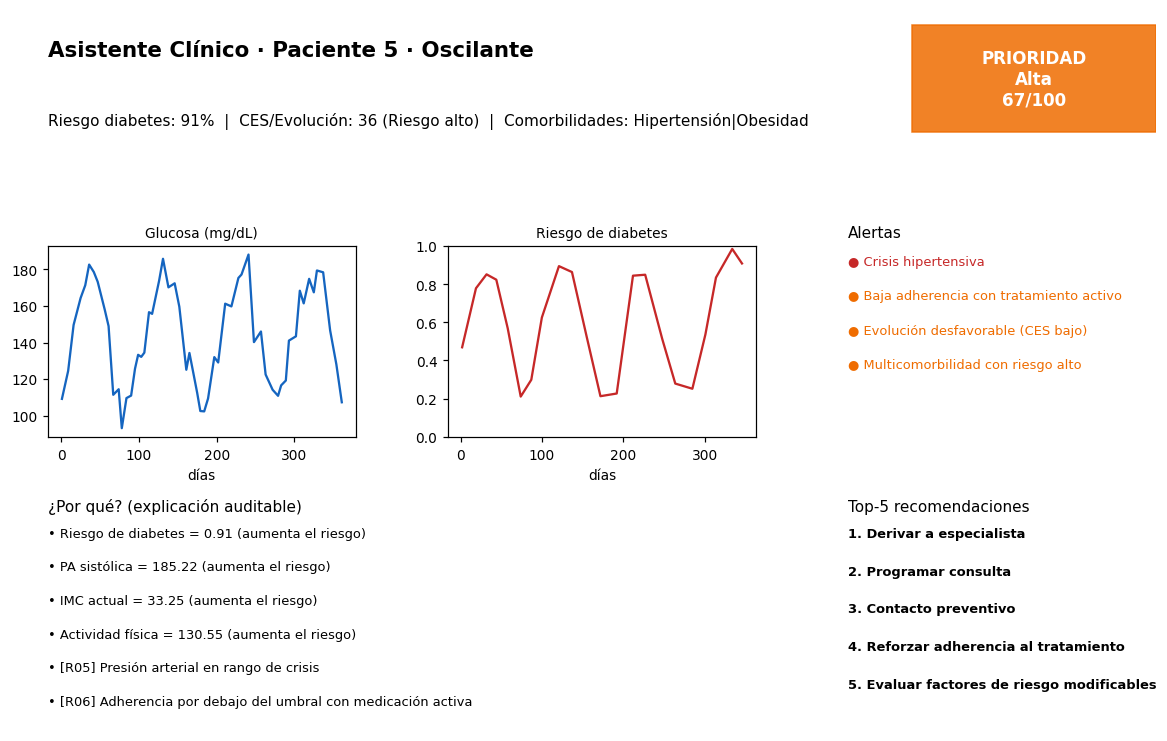

In [4]:
for p in sorted(DASH.glob('asistente_*.png')): show(p)

### Conclusión 3H
- **Consistente:** prioridad monótona con el riesgo (ρ≈0.95) e inversa al CES.
- **Interpretable y auditable:** 100% de recomendaciones con razón y traza.
- **Reduce carga cognitiva:** ~5 acciones priorizadas vs catálogo completo.
- **Valor clínico:** la prioridad separa a quienes se deterioran de quienes no.

El PCDSS responde *¿qué debería hacerse con este paciente?* de forma justificada y trazable, listo para integrarse en PREDIA (`Clinical_Decision_Support_Report.md`).